# Experiment 3: Multimodal Late-Fusion Network

This notebook trains a **Multimodal Late-Fusion Model** combining:
- **RGB Imagery (B4, B3, B2)** processed via a pre-trained **ResNet50** (ImageNet weights)
- **Terrain & Infrared (B8, DEM, Slope)** processed via a **Custom CNN** to extract complementary spectral and topographic characteristics that are not fully represented by RGB imagery.

The output features are concatenated and passed through a Fusion Head.

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_recall_curve
)

import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 1. Geographic Data Split (Consistent with previous experiments)

In [4]:
metadata_path = 'dataset_version_2/metadata.csv'
df = pd.read_csv(metadata_path)

# Update path from dataset_version_2 to dataset_proposed (where .npy are saved)
# Replace 'dataset_version_2/positive/landslide_X.png' with 'dataset_proposed/positive/landslide_X.npy'
df['npy_path'] = df['image_path'].str.replace('dataset_version_2', 'dataset_proposed').str.replace('.png', '.npy')

# Ensure files exist
df = df[df['npy_path'].apply(os.path.exists)].reset_index(drop=True)
print(f'Total valid patches: {len(df)}')

gss1 = GroupShuffleSplit(n_splits=1, train_size=0.7, random_state=42)
train_idx, temp_idx = next(gss1.split(df, groups=df['landslide_id']))

df_train = df.iloc[train_idx].copy()
df_temp = df.iloc[temp_idx].copy()

gss2 = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=42)
val_idx, test_idx = next(gss2.split(df_temp, groups=df_temp['landslide_id']))

df_val = df_temp.iloc[val_idx].copy()
df_test = df_temp.iloc[test_idx].copy()

print(f'Train size: {len(df_train)} | Val size: {len(df_val)} | Test size: {len(df_test)}')

pos_count = df_train['label'].sum()
neg_count = len(df_train) - pos_count
pos_weight = torch.tensor([neg_count / pos_count]).to(device)
print(f'Pos weight for Loss function: {pos_weight.item():.4f}')

Total valid patches: 8338
Train size: 5836 | Val size: 1255 | Test size: 1247
Pos weight for Loss function: 1.0027


## 2. 6-Channel Dataset and Splitting Logic

In [5]:
class MultimodalLandslideDataset(Dataset):
    def __init__(self, dataframe, is_train=False):
        self.dataframe = dataframe
        self.is_train = is_train
        
        # ImageNet normalization ONLY for the RGB branch
        self.rgb_normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                                  std=[0.229, 0.224, 0.225])
        
        # Note: NIR, DEM, and Slope were already normalized to [0, 1] during download.
        # DEM   : 0-3000m
        # Slope : 0-90°
        # NIR   : 0-5000 reflectance
        
    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        npy_path = self.dataframe.iloc[idx]['npy_path']
        # Shape is (6, 224, 224)
        data = np.load(npy_path).astype(np.float32)
        
        # Split into RGB and Terrain
        # Channels 0,1,2: B4, B3, B2 (RGB)
        # Channels 3,4,5: B8, DEM, Slope (Terrain+NIR)
        rgb_data = data[0:3, :, :]
        terrain_data = data[3:6, :, :]
        
        rgb_tensor = torch.tensor(rgb_data)
        terrain_tensor = torch.tensor(terrain_data)
        
        # Data augmentation ONLY for training
        if self.is_train:
            if torch.rand(1) > 0.5:
                rgb_tensor = torch.flip(rgb_tensor, [2])
                terrain_tensor = torch.flip(terrain_tensor, [2])
            if torch.rand(1) > 0.5:
                rgb_tensor = torch.flip(rgb_tensor, [1])
                terrain_tensor = torch.flip(terrain_tensor, [1])
                
        # Apply proper ImageNet Normalization to RGB branch
        rgb_tensor = self.rgb_normalize(rgb_tensor)
        
        label = float(self.dataframe.iloc[idx]['label'])
        return rgb_tensor, terrain_tensor, torch.tensor(label, dtype=torch.float32)

batch_size = 32
train_loader = DataLoader(MultimodalLandslideDataset(df_train, is_train=True), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(MultimodalLandslideDataset(df_val, is_train=False), batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(MultimodalLandslideDataset(df_test, is_train=False), batch_size=batch_size, shuffle=False)

## 3. Multimodal Network Architecture

In [6]:
class TerrainCNN(nn.Module):
    def __init__(self):
        super(TerrainCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))  # Output: 256 x 1 x 1
        )
        
    def forward(self, x):
        x = self.features(x)
        return x.view(x.size(0), -1)  # Flatten to 256

class MultimodalLandslideModel(nn.Module):
    def __init__(self):
        super(MultimodalLandslideModel, self).__init__()
        
        # Branch 1: Pre-trained ResNet50
        self.resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        # Remove the classification head, keep up to avgpool (outputs 2048)
        self.resnet = nn.Sequential(*list(self.resnet.children())[:-1]) 
        
        # Branch 2: Custom Terrain CNN
        self.terrain_cnn = TerrainCNN()
        
        # Fusion Head: 2048 + 256 = 2304
        self.fusion_head = nn.Sequential(
            nn.Linear(2304, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 1)
        )
        
    def forward(self, rgb, terrain):
        # Process RGB
        f_rgb = self.resnet(rgb)
        f_rgb = f_rgb.view(f_rgb.size(0), -1)  # Flatten to 2048
        
        # Process Terrain
        f_terrain = self.terrain_cnn(terrain)  # Flatten to 256
        
        # Concatenate features
        f_combined = torch.cat((f_rgb, f_terrain), dim=1) # 2304
        
        # Final prediction
        out = self.fusion_head(f_combined)
        return out

model = MultimodalLandslideModel().to(device)
print(f'Total trainable params (initially): {sum(p.numel() for p in model.parameters() if p.requires_grad)}')


Total trainable params (initially): 25079105


## 4. Training Utilities

In [7]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

def train_multimodal(model, optimizer, scheduler, num_epochs=20, patience=5, save_path='best_multimodal.pth'):
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for rgb, terrain, labels in train_loader:
            rgb, terrain, labels = rgb.to(device), terrain.to(device), labels.to(device).unsqueeze(1)
            optimizer.zero_grad()
            outputs = model(rgb, terrain)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * rgb.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for rgb, terrain, labels in val_loader:
                rgb, terrain, labels = rgb.to(device), terrain.to(device), labels.to(device).unsqueeze(1)
                outputs = model(rgb, terrain)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * rgb.size(0)

        epoch_val_loss = val_loss / len(val_loader.dataset)
        scheduler.step(epoch_val_loss)
        print(f'Epoch {epoch+1:02d}/{num_epochs} | Train Loss: {epoch_loss:.4f} | Val Loss: {epoch_val_loss:.4f}')

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print('Early stopping triggered!')
                break

    model.load_state_dict(torch.load(save_path, weights_only=True))
    return model

def find_optimal_threshold_multimodal(model):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for rgb, terrain, labels in val_loader:
            rgb, terrain = rgb.to(device), terrain.to(device)
            outputs = model(rgb, terrain)
            probs = torch.sigmoid(outputs).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())

    y_true = np.array(all_labels).flatten()
    y_prob = np.array(all_probs).flatten()
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_threshold = thresholds[f1_scores[:-1].argmax()]
    print(f'Optimal threshold (from val set): {best_threshold:.4f}')
    return best_threshold

def evaluate_multimodal(model, name, threshold=0.5):
    model.eval()
    test_preds, test_targets = [], []
    with torch.no_grad():
        for rgb, terrain, labels in test_loader:
            rgb, terrain = rgb.to(device), terrain.to(device)
            outputs = model(rgb, terrain)
            probs = torch.sigmoid(outputs)
            test_preds.extend(probs.cpu().numpy())
            test_targets.extend(labels.numpy())

    y_true = np.array(test_targets).flatten()
    y_prob = np.array(test_preds).flatten()
    y_pred = (y_prob >= threshold).astype(int)

    print(f"\n{'='*40}\n--- Evaluation: {name} (threshold={threshold:.3f}) ---\n{'='*40}")
    print(classification_report(y_true, y_pred, target_names=['No Landslide', 'Landslide']))

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp)
    auc = roc_auc_score(y_true, y_prob)

    print(f'Specificity:  {specificity:.4f}')
    print(f'ROC-AUC:      {auc:.4f}')
    print(f'TP: {tp}  TN: {tn}  FP: {fp}  FN: {fn}')

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    plt.title(f'{name} Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'saved_models/{name.replace(" ", "_")}_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()


## 5. Stage 1: Train Head + Custom Terrain CNN (ResNet Frozen)

In [8]:
print('--- Stage 1: Training Custom Terrain CNN & Fusion Head (ResNet50 Frozen) ---')

# Freeze ResNet50
for param in model.resnet.parameters():
    param.requires_grad = False

# Ensure Terrain CNN and Fusion Head are unfrozen
for param in model.terrain_cnn.parameters():
    param.requires_grad = True
for param in model.fusion_head.parameters():
    param.requires_grad = True

# Global LR for the active parts
optimizer_s1 = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
scheduler_s1 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_s1, mode='min', factor=0.5, patience=3)

model = train_multimodal(model, optimizer_s1, scheduler_s1, num_epochs=20, patience=6, save_path='saved_models/multimodal_stage1.pth')

--- Stage 1: Training Custom Terrain CNN & Fusion Head (ResNet50 Frozen) ---
Epoch 01/20 | Train Loss: 0.6812 | Val Loss: 0.6434
Epoch 02/20 | Train Loss: 0.6525 | Val Loss: 0.6320
Epoch 03/20 | Train Loss: 0.6385 | Val Loss: 0.6249
Epoch 04/20 | Train Loss: 0.6187 | Val Loss: 0.6101
Epoch 05/20 | Train Loss: 0.6142 | Val Loss: 0.6168
Epoch 06/20 | Train Loss: 0.5991 | Val Loss: 0.6174
Epoch 07/20 | Train Loss: 0.5981 | Val Loss: 0.6354
Epoch 08/20 | Train Loss: 0.5928 | Val Loss: 0.6003
Epoch 09/20 | Train Loss: 0.5874 | Val Loss: 0.6150
Epoch 10/20 | Train Loss: 0.5865 | Val Loss: 0.6192
Epoch 11/20 | Train Loss: 0.5717 | Val Loss: 0.6106
Epoch 12/20 | Train Loss: 0.5710 | Val Loss: 0.5980
Epoch 13/20 | Train Loss: 0.5669 | Val Loss: 0.6120
Epoch 14/20 | Train Loss: 0.5660 | Val Loss: 0.6014
Epoch 15/20 | Train Loss: 0.5527 | Val Loss: 0.5889
Epoch 16/20 | Train Loss: 0.5590 | Val Loss: 0.5822
Epoch 17/20 | Train Loss: 0.5410 | Val Loss: 0.5957
Epoch 18/20 | Train Loss: 0.5464 | Val 

## 6. Stage 2: Partial Fine-Tuning with Differential Learning Rates

In [9]:
print('\n--- Stage 2: Partial Fine-Tuning with Differential Learning Rates ---')

# Unfreeze ResNet layer4
for name, child in model.resnet.named_children():
    if name == '7': # In Sequential ResNet up to avgpool, '7' is typically layer4
        for param in child.parameters():
            param.requires_grad = True

# -----------------------------------------------------
# CRITICAL: Differential Learning Rates implementation
# ResNet layer1-3 -> Frozen
# ResNet layer4 -> Trainable (LR = 1e-5)
# Custom CNN    -> Trainable (LR = 1e-4)
# Fusion Head   -> Trainable (LR = 1e-4)
# -----------------------------------------------------
optimizer_s2 = optim.Adam([
    {'params': model.resnet[7].parameters(), 'lr': 1e-5},
    {'params': model.terrain_cnn.parameters(), 'lr': 1e-4},
    {'params': model.fusion_head.parameters(), 'lr': 1e-4}
])

scheduler_s2 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_s2, mode='min', factor=0.5, patience=3)

model = train_multimodal(model, optimizer_s2, scheduler_s2, num_epochs=15, patience=5, save_path='saved_models/multimodal_stage2.pth')


--- Stage 2: Partial Fine-Tuning with Differential Learning Rates ---
Epoch 01/15 | Train Loss: 0.5553 | Val Loss: 0.6131
Epoch 02/15 | Train Loss: 0.5453 | Val Loss: 0.5959
Epoch 03/15 | Train Loss: 0.5377 | Val Loss: 0.6127
Epoch 04/15 | Train Loss: 0.5320 | Val Loss: 0.6032
Epoch 05/15 | Train Loss: 0.5244 | Val Loss: 0.5781
Epoch 06/15 | Train Loss: 0.5142 | Val Loss: 0.5731
Epoch 07/15 | Train Loss: 0.5086 | Val Loss: 0.5742
Epoch 08/15 | Train Loss: 0.4847 | Val Loss: 0.5885
Epoch 09/15 | Train Loss: 0.4900 | Val Loss: 0.6118
Epoch 10/15 | Train Loss: 0.4837 | Val Loss: 0.5850
Epoch 11/15 | Train Loss: 0.4630 | Val Loss: 0.5777
Early stopping triggered!


## 7. Evaluation

Optimal threshold (from val set): 0.2913

--- Evaluation: Multimodal Late-Fusion (Exp 3) (threshold=0.291) ---
              precision    recall  f1-score   support

No Landslide       0.79      0.35      0.49       620
   Landslide       0.59      0.91      0.71       627

    accuracy                           0.63      1247
   macro avg       0.69      0.63      0.60      1247
weighted avg       0.69      0.63      0.60      1247

Specificity:  0.3500
ROC-AUC:      0.7371
TP: 570  TN: 217  FP: 403  FN: 57


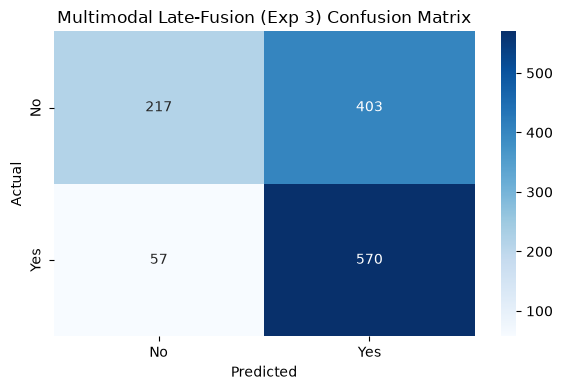

In [10]:
opt_thresh = find_optimal_threshold_multimodal(model)
evaluate_multimodal(model, 'Multimodal Late-Fusion (Exp 3)', threshold=opt_thresh)